<a href="https://colab.research.google.com/github/santimsoler/APLICACIONFINAL_PROGRAMACION_UBA/blob/main/CASEN2024_analisis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción y Determinantes de la Pobreza Multidimensional y Vulnerabilidad
### CASEN 2024 — Taller de Programación, UBA 2026 — Grupo 2

Notebook de arranque: carga de datos, cruce con la base de provincia/comuna, definición de la unidad de análisis y primera limpieza. Pensado para correr en **Google Colab**.


## 1. Setup

In [1]:
!pip install pyreadstat -q
import pandas as pd
import numpy as np
import pyreadstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 27.9 MB/s eta 0:00:00


## 2. Cargar los datos

En tu carpeta `CASEN2024/` de Drive ya tenés `casen_2024.dta` suelto (no hace falta descomprimir ningún zip) y `casen_2024_provincia_comuna.dta` también suelto.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Ajustar el path según donde hayas guardado los archivos en tu Drive
RUTA = '/content/drive/MyDrive/CASEN2024/'

# Base principal (877 variables) — ya está descomprimida en Drive
df, meta = pyreadstat.read_dta(RUTA + 'casen_2024.dta')

# Base complementaria de provincia y comuna (folio, id_persona, provincia, comuna, expp, expc)
df_geo, meta_geo = pyreadstat.read_dta(RUTA + 'casen_2024_provincia_comuna.dta')

print(df.shape, df_geo.shape)

Mounted at /content/drive
(218367, 877) (218367, 6)


## 3. Cruzar ambas bases

Según la *Nota de uso de bases de datos Casen 2024*, la llave de cruce es **folio + id_persona**.

In [3]:
df = df.merge(df_geo[['folio', 'id_persona', 'provincia', 'comuna', 'expp', 'expc']],
              on=['folio', 'id_persona'], how='left')
df.shape

(218367, 881)

In [4]:
if 'pco1_a' in df.columns:
    print("La columna 'pco1_a' existe en el DataFrame df.")
else:
    print("La columna 'pco1_a' NO existe en el DataFrame df.")

La columna 'pco1_a' existe en el DataFrame df.


## 4. Definir la unidad de análisis: hogar

Trabajamos a nivel de **hogar**, usando `folio` como identificador y filtrando por jefatura de hogar (`pco1_a == 1`) para no repetir observaciones dentro de un mismo hogar.

In [5]:
## Parte 4: Definir la unidad de análisis (hogar) y tratar la variable objetivo

# Filtrar a nivel de hogar: un registro por hogar, usando la jefatura (pco1_a == 1)
hogares = df[df['pco1_a'] == 1].copy()
print('Hogares:', hogares.shape[0])

# Diagnóstico de nulos en la variable objetivo
n_nulos = hogares['pobreza_multi'].isna().sum()
pct_nulos = n_nulos / hogares.shape[0] * 100
print(f"Valores nulos en 'pobreza_multi': {n_nulos}")
print(f"Porcentaje de valores nulos en 'pobreza_multi': {pct_nulos:.2f}%")

# CORRECTO: descartar los hogares sin dato válido de pobreza_multi, NUNCA imputar el target.
# Imputar la variable que se quiere predecir (con la mediana o cualquier otro valor) sesga
# artificialmente la tasa de pobreza hacia la clase mayoritaria (acá, "no pobre").
hogares = hogares.dropna(subset=['pobreza_multi']).copy()
print('Hogares con pobreza_multi válida:', hogares.shape[0])

# Tasa de pobreza multidimensional (sin ponderar y ponderada con el factor de expansión regional)
tasa = hogares['pobreza_multi'].mean() * 100
tasa_expandida = np.average(hogares['pobreza_multi'], weights=hogares['expr'])
print(f'Tasa de pobreza multidimensional (sin ponderar): {tasa:.1f}%')
print(f'Tasa de pobreza multidimensional (ponderada, expr): {tasa_expandida*100:.1f}%')

Hogares: 78654
Valores nulos en 'pobreza_multi': 1889
Porcentaje de valores nulos en 'pobreza_multi': 2.40%
Hogares con pobreza_multi válida: 76765
Tasa de pobreza multidimensional (sin ponderar): 13.6%
Tasa de pobreza multidimensional (ponderada, expr): 13.4%


## 5. Variable objetivo

`pobreza_multi`: 0 = hogar fuera de pobreza multidimensional, 1 = hogar en pobreza multidimensional.

In [6]:
hogares['pobreza_multi'].value_counts(dropna=False)
tasa = hogares['pobreza_multi'].mean() * 100
print(f'Tasa de pobreza multidimensional (sin ponderar): {tasa:.1f}%')

# Con factor de expansión regional (representativo a nivel nacional)
tasa_expandida = np.average(hogares['pobreza_multi'], weights=hogares['expr'])
print(f'Tasa de pobreza multidimensional (ponderada, expr): {tasa_expandida*100:.1f}%')

Tasa de pobreza multidimensional (sin ponderar): 13.6%
Tasa de pobreza multidimensional (ponderada, expr): 13.4%


## 6. Selección de variables predictoras (no monetarias)

⚠️ **No usamos las variables `hh_d_*`** (carencias) como predictoras porque son los componentes que construyen `pobreza_multi` — usarlas sería circular. Partimos de las variables crudas de los módulos S (Salud), E (Educación) y V (Vivienda).

In [7]:
predictores_salud = ['s13', 's16', 's17', 's19a', 's19b', 's19c', 's19d', 's19e', 's2']
predictores_educacion = ['educ']  # crear a partir de CH12/CH13/CH14 si no viene calculada; revisar libro de códigos módulo E
predictores_vivienda = ['v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v12', 'v13']

predictores = predictores_salud + predictores_educacion + predictores_vivienda
predictores = [c for c in predictores if c in hogares.columns]
print('Predictores disponibles:', predictores)

base_modelo = hogares[['folio', 'provincia', 'comuna', 'expr', 'pobreza_multi'] + predictores].copy()
base_modelo.head()

Predictores disponibles: ['s13', 's16', 's17', 's19a', 's19b', 's19c', 's19d', 's19e', 's2', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v12', 'v13']


,folio,provincia,comuna,expr,pobreza_multi,s13,s16,s17,s19a,s19b,...,s19e,s2,v2,v3,v4,v5,v6,v7,v12,v13
0,100020301,131,13127,264,0,1,4,2,NaN,NaN,...,NaN,NaN,2,2,1,1,3,2,3,1
2,100020401,131,13127,295,0,1,5,NaN,NaN,NaN,...,NaN,NaN,2,1,1,1,3,1,4,2
6,100020501,131,13127,373,0,1,2,1,2,2,...,2,NaN,3,3,5,3,3,3,3,3
7,100020801,131,13127,266,0,1,5,NaN,NaN,NaN,...,NaN,NaN,2,2,1,1,3,1,4,1
12,100070201,22,2203,72,0,1,5,NaN,NaN,NaN,...,NaN,NaN,2,1,2,1,3,1,2,1


## 7. Limpieza: valores perdidos y códigos especiales

Revisar los códigos de "No sabe/No responde" del libro de códigos para cada variable (suelen venir como 88, 99, -88, -99 según el módulo) y decidir imputación o exclusión antes de modelar.

In [8]:
base_modelo.isna().sum().sort_values(ascending=False)

,0
s2,76765
s19a,61165
s19b,61007
s19c,61007
s19e,61007
s19d,61007
s17,59447
pobreza_multi,0
s13,0
comuna,0


### Análisis de Correlación

Analicemos la correlación de las variables predictoras con `pobreza_multi` para entender sus relaciones.

Correlación con 'pobreza_multi':
pobreza_multi    1.000000
v3               0.248425
v7               0.241634
v5               0.241347
v4               0.136229
v2               0.111083
v13              0.106844
v6               0.079800
s17              0.015474
s16             -0.005329
s13             -0.016126
s19d            -0.023613
v12             -0.024402
s19a            -0.029981
s19e            -0.037154
s19c            -0.044403
s19b            -0.047045
s2                    NaN
Name: pobreza_multi, dtype: float64


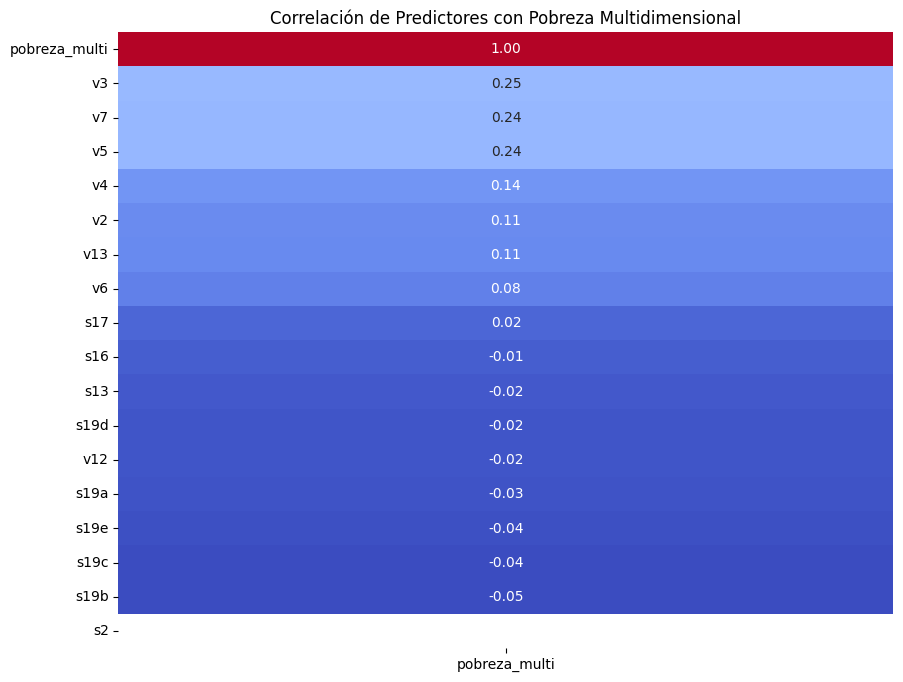

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar las columnas relevantes para la correlación
columnas_correlacion = ['pobreza_multi'] + predictores

# Asegurarse de que todas las columnas existen en base_modelo
columnas_correlacion = [col for col in columnas_correlacion if col in base_modelo.columns]

# Calcular la matriz de correlación
correlacion = base_modelo[columnas_correlacion].corr()

# Obtener las correlaciones con 'pobreza_multi' y ordenarlas
correlacion_pobreza_multi = correlacion['pobreza_multi'].sort_values(ascending=False)

# Mostrar las correlaciones
print("Correlación con 'pobreza_multi':")
print(correlacion_pobreza_multi)

# Opcional: Visualizar las correlaciones con un heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlacion_pobreza_multi.to_frame(), annot=True, cmap='coolwarm', fmt=".2f", cbar=False)
plt.title('Correlación de Predictores con Pobreza Multidimensional')
plt.show()

## 8. Guardar la base limpia

Para no volver a levantar los archivos pesados (.dta/.sav) en cada corrida, guardamos un CSV liviano con las variables ya seleccionadas — este es el archivo que subimos al repo de GitHub (los .dta/.sav originales NO se suben, van en `.gitignore`).

In [11]:
base_modelo.to_csv('base_modelo_casen2024.csv', index=False)
from google.colab import files
files.download('base_modelo_casen2024.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9. Módulo de Redes y Cohesión Social (sugerencia de Noelia)

Sumamos variables de **red de apoyo** (r7) e **inseguridad alimentaria** (r8) — no forman parte de las carencias oficiales del IPM, así que aportan información nueva sobre el "background" del hogar.

In [10]:
predictores_redes_apoyo = ['r7a', 'r7b', 'r7c', 'r7d', 'r7e', 'r7f', 'r7g', 'r7h', 'r7i']  # cuenta con ayuda en...
predictores_inseg_alimentaria = ['r8a', 'r8b', 'r8c', 'r8d', 'r8e', 'r8f', 'r8g', 'r8h']  # escala de inseguridad alimentaria
predictores_activos = ['r14', 'r15']  # tenencia y cantidad de vehículos

predictores_redes = predictores_redes_apoyo + predictores_inseg_alimentaria + predictores_activos
predictores_redes = [c for c in predictores_redes if c in hogares.columns]

predictores = predictores + predictores_redes
base_modelo = hogares[['folio', 'provincia', 'comuna', 'expr', 'pobreza_multi'] + predictores].copy()
print('Total predictores:', len(predictores))
base_modelo.head()

Total predictores: 36


,folio,provincia,comuna,expr,pobreza_multi,s13,s16,s17,s19a,s19b,...,r8a,r8b,r8c,r8d,r8e,r8f,r8g,r8h,r14,r15
0,100020301,131,13127,264,0,1,4,2,NaN,NaN,...,2,2,2,2,2,2,2,2,2,NaN
2,100020401,131,13127,295,0,1,5,NaN,NaN,NaN,...,2,2,2,2,2,2,2,2,1,2
6,100020501,131,13127,373,0,1,2,1,2,2,...,2,2,2,2,2,2,2,2,2,NaN
7,100020801,131,13127,266,0,1,5,NaN,NaN,NaN,...,1,1,1,1,1,1,1,2,1,1
12,100070201,22,2203,72,0,1,5,NaN,NaN,NaN,...,2,2,2,2,2,2,2,2,1,2


### Recálculo de predictores y `base_modelo` (incluyendo variables de redes) y Análisis de Correlación

In [12]:
predictores_salud = ['s13', 's16', 's17', 's19a', 's19b', 's19c', 's19d', 's19e', 's2']
predictores_educacion = ['educ']
predictores_vivienda = ['v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v12', 'v13']

predictores = predictores_salud + predictores_educacion + predictores_vivienda
predictores = [c for c in predictores if c in hogares.columns]

predictores_redes_apoyo = ['r7a', 'r7b', 'r7c', 'r7d', 'r7e', 'r7f', 'r7g', 'r7h', 'r7i']
predictores_inseg_alimentaria = ['r8a', 'r8b', 'r8c', 'r8d', 'r8e', 'r8f', 'r8g', 'r8h']
predictores_activos = ['r14', 'r15']

predictores_redes = predictores_redes_apoyo + predictores_inseg_alimentaria + predictores_activos
predictores_redes = [c for c in predictores_redes if c in hogares.columns]

predictores = predictores + predictores_redes

base_modelo = hogares[['folio', 'provincia', 'comuna', 'expr', 'pobreza_multi'] + predictores].copy()
print('Total predictores:', len(predictores))
print('Primeras filas de base_modelo con predictores actualizados:')
display(base_modelo.head())

Total predictores: 36
Primeras filas de base_modelo con predictores actualizados:


,folio,provincia,comuna,expr,pobreza_multi,s13,s16,s17,s19a,s19b,...,r8a,r8b,r8c,r8d,r8e,r8f,r8g,r8h,r14,r15
0,100020301,131,13127,264,0,1,4,2,NaN,NaN,...,2,2,2,2,2,2,2,2,2,NaN
2,100020401,131,13127,295,0,1,5,NaN,NaN,NaN,...,2,2,2,2,2,2,2,2,1,2
6,100020501,131,13127,373,0,1,2,1,2,2,...,2,2,2,2,2,2,2,2,2,NaN
7,100020801,131,13127,266,0,1,5,NaN,NaN,NaN,...,1,1,1,1,1,1,1,2,1,1
12,100070201,22,2203,72,0,1,5,NaN,NaN,NaN,...,2,2,2,2,2,2,2,2,1,2


Correlación con 'pobreza_multi':
pobreza_multi    1.000000
v3               0.248425
v7               0.241634
v5               0.241347
v4               0.136229
r14              0.119412
v2               0.111083
v13              0.106844
v6               0.079800
r7e              0.047247
r7c              0.041682
r7f              0.036897
r7g              0.035171
r7h              0.033043
r7d              0.032323
r7a              0.030870
r7i              0.028598
r7b              0.018319
s17              0.015474
s16             -0.005329
r15             -0.015283
s13             -0.016126
s19d            -0.023613
v12             -0.024402
s19a            -0.029981
s19e            -0.037154
s19c            -0.044403
s19b            -0.047045
r8h             -0.253209
r8a             -0.293654
r8f             -0.306308
r8g             -0.311273
r8b             -0.330193
r8d             -0.337657
r8c             -0.340585
r8e             -0.363672
s2                    NaN
Name:

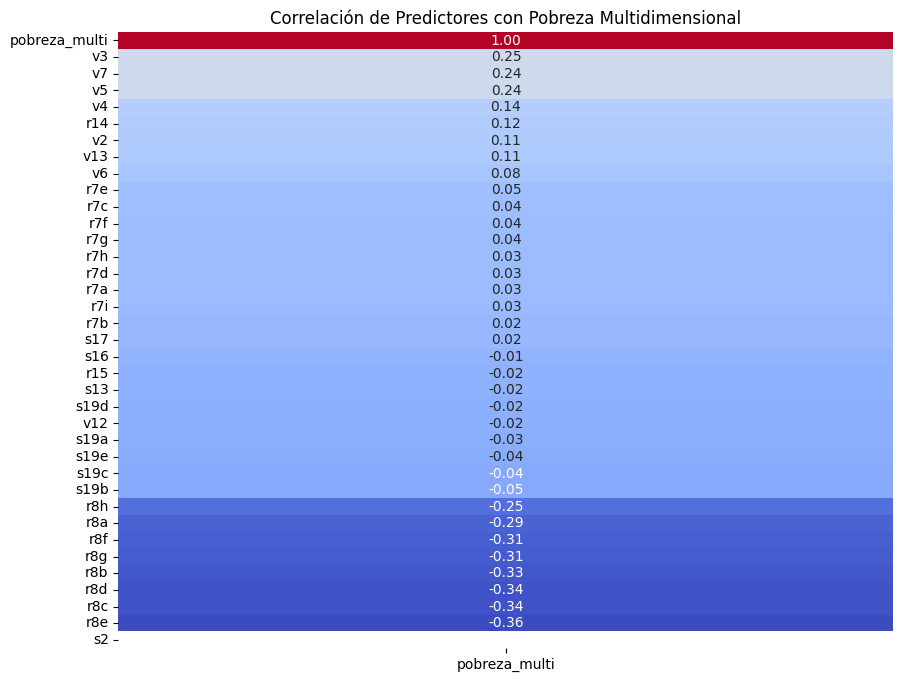

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar las columnas relevantes para la correlación
columnas_correlacion = ['pobreza_multi'] + predictores

# Asegurarse de que todas las columnas existen en base_modelo
columnas_correlacion = [col for col in columnas_correlacion if col in base_modelo.columns]

# Calcular la matriz de correlación
correlacion = base_modelo[columnas_correlacion].corr()

# Obtener las correlaciones con 'pobreza_multi' y ordenarlas
correlacion_pobreza_multi = correlacion['pobreza_multi'].sort_values(ascending=False)

# Mostrar las correlaciones
print("Correlación con 'pobreza_multi':")
print(correlacion_pobreza_multi)

# Opcional: Visualizar las correlaciones con un heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlacion_pobreza_multi.to_frame(), annot=True, cmap='coolwarm', fmt=".2f", cbar=False)
plt.title('Correlación de Predictores con Pobreza Multidimensional')
plt.show()

### Preparación de Datos para el Modelado

Antes de entrenar el modelo, necesitamos:
1. Manejar los valores faltantes en las variables predictoras.
2. Dividir los datos en conjuntos de entrenamiento y prueba.
3. Escalar las características.

In [14]:
# 1. Manejo de valores faltantes en los predictores
print("Valores nulos por predictor antes de la imputación:")
missing_values_before = base_modelo[predictores].isnull().sum()
print(missing_values_before[missing_values_before > 0])

# Identificar columnas con todos los valores NaN para eliminarlas (ej. 's2' en la correlación)
columns_to_drop_for_nan = [col for col in predictores if base_modelo[col].isnull().all()]
if columns_to_drop_for_nan:
    print(f"Columnas con todos los valores NaN que se eliminarán: {columns_to_drop_for_nan}")
    base_modelo = base_modelo.drop(columns=columns_to_drop_for_nan)
    predictores = [p for p in predictores if p not in columns_to_drop_for_nan]
    print(f"Predictores restantes: {len(predictores)}")

# Para variables categóricas/ordinales, imputar NaN con un valor como -1 (que indica 'desconocido' o 'no aplica')
# Para variables numéricas continuas (si las hubiera), se podría usar la mediana o la media.
# Dada la naturaleza de los datos de encuesta, -1 es una opción común.
for col in predictores:
    if base_modelo[col].dtype == 'object': # Handle potential object type if not converted to numeric
        base_modelo[col] = pd.to_numeric(base_modelo[col], errors='coerce')
    base_modelo[col] = base_modelo[col].fillna(-1)

print("\nValores nulos por predictor después de la imputación:")
missing_values_after = base_modelo[predictores].isnull().sum()
print(missing_values_after[missing_values_after > 0])

# Verificar la columna 's2' específicamente si sigue en los predictores
if 's2' in predictores:
    print(f"'s2' tiene {base_modelo['s2'].isnull().sum()} valores nulos después de la imputación.")

Valores nulos por predictor antes de la imputación:
s17     59447
s19a    61165
s19b    61007
s19c    61007
s19d    61007
s19e    61007
s2      76765
r15     36791
dtype: int64
Columnas con todos los valores NaN que se eliminarán: ['s2']
Predictores restantes: 35

Valores nulos por predictor después de la imputación:
Series([], dtype: int64)


### División de Datos y Escalado de Características

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Definir X (features) e y (target)
X = base_modelo[predictores]
y = base_modelo['pobreza_multi']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de X_test: {X_test.shape}")
print(f"Distribución de clases en y_train:\n{y_train.value_counts(normalize=True)}")
print(f"Distribución de clases en y_test:\n{y_test.value_counts(normalize=True)}")

# Escalar las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Características escaladas completadas.")

Forma de X_train: (53735, 35)
Forma de X_test: (23030, 35)
Distribución de clases en y_train:
pobreza_multi
0    0.864241
1    0.135759
Name: proportion, dtype: float64
Distribución de clases en y_test:
pobreza_multi
0    0.864264
1    0.135736
Name: proportion, dtype: float64
Características escaladas completadas.


### Entrenamiento del Modelo de Clasificación (Regresión Logística)

Usaremos un modelo de Regresión Logística como punto de partida para la clasificación.

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Inicializar y entrenar el modelo de Regresión Logística
model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced') # 'balanced' para manejar desbalance de clases

# Convert y_train and y_test to integer type to ensure discrete classes
y_train_int = y_train.astype(int)
y_test_int = y_test.astype(int)

model.fit(X_train_scaled, y_train_int)

# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test_scaled)

# Evaluar el modelo
print("\n--- Informe de Clasificación ---")
print(classification_report(y_test_int, y_pred))

print("\n--- Matriz de Confusión ---")
print(confusion_matrix(y_test_int, y_pred))


--- Informe de Clasificación ---
              precision    recall  f1-score   support

           0       0.94      0.80      0.86     19904
           1       0.35      0.69      0.46      3126

    accuracy                           0.78     23030
   macro avg       0.65      0.74      0.66     23030
weighted avg       0.86      0.78      0.81     23030


--- Matriz de Confusión ---
[[15871  4033]
 [  969  2157]]


## 10. Filtrar los hogares pobres

Siguiendo la indicación de Noelia: no buscamos separar pobres de no pobres (ya lo hace `pobreza_multi`), sino segmentar **dentro del grupo de pobres** para encontrar a los más severos.

In [17]:
pobres = base_modelo[base_modelo['pobreza_multi'] == 1].copy()
print('Hogares pobres:', pobres.shape[0])
pobres = pobres.dropna(subset=predictores_redes)  # nos quedamos con los que tienen dato completo en redes/alimentación
print('Hogares pobres con datos completos de redes:', pobres.shape[0])

Hogares pobres: 10421
Hogares pobres con datos completos de redes: 10421


## 11. Elegir el número de clusters (k) de forma rigurosa

En vez de fijar k a mano, probamos varios valores y usamos dos criterios estándar para elegir el óptimo:

- **Método del codo (inertia)**: dónde la reducción de inercia empieza a aplanarse
- **Silhouette score**: qué tan bien separados y compactos quedan los clusters (más cerca de 1 es mejor)

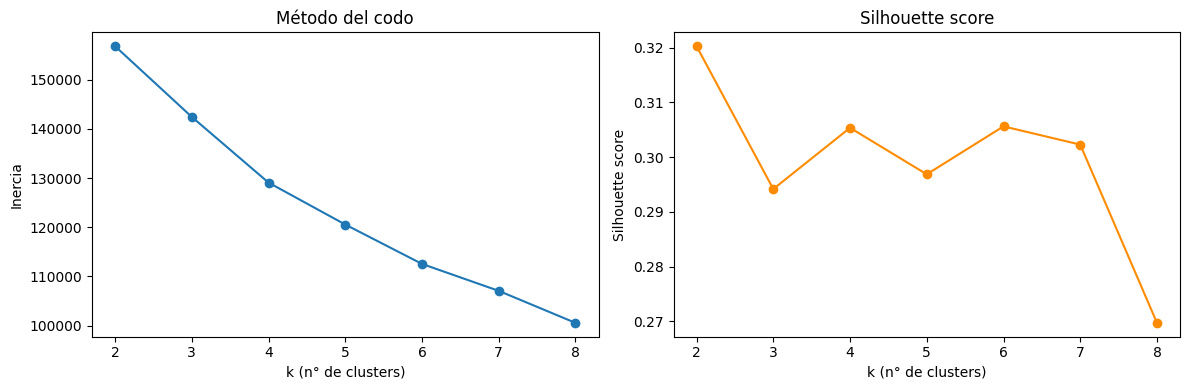

k=2: inertia=156833.2, silhouette=0.320
k=3: inertia=142441.5, silhouette=0.294
k=4: inertia=129074.5, silhouette=0.305
k=5: inertia=120542.1, silhouette=0.297
k=6: inertia=112530.4, silhouette=0.306
k=7: inertia=107047.7, silhouette=0.302
k=8: inertia=100532.5, silhouette=0.270


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

X = pobres[predictores_redes].apply(pd.to_numeric, errors='coerce').fillna(0)
X_scaled = StandardScaler().fit_transform(X)

k_values = range(2, 9)
inertias = []
silhouettes = []

for k in k_values:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_values), inertias, marker='o')
axes[0].set_title('Método del codo')
axes[0].set_xlabel('k (n° de clusters)')
axes[0].set_ylabel('Inercia')

axes[1].plot(list(k_values), silhouettes, marker='o', color='darkorange')
axes[1].set_title('Silhouette score')
axes[1].set_xlabel('k (n° de clusters)')
axes[1].set_ylabel('Silhouette score')

plt.tight_layout()
plt.show()

for k, inertia, sil in zip(k_values, inertias, silhouettes):
    print(f'k={k}: inertia={inertia:.1f}, silhouette={sil:.3f}')

## 12. Correr k-means con el k elegido

Miren el gráfico de la celda anterior: elijan el k donde el codo se "quiebra" (deja de bajar mucho la inercia) y que además tenga buen silhouette score. Reemplacen `K_ELEGIDO` por ese valor antes de correr — no lo dejen fijo en 3 sin mirar el gráfico.

In [19]:
K_ELEGIDO = 3  # <-- reemplazar según el gráfico de la celda anterior

kmeans = KMeans(n_clusters=K_ELEGIDO, n_init=20, random_state=42)
pobres['cluster_severidad'] = kmeans.fit_predict(X_scaled)

pobres.groupby('cluster_severidad')[predictores_redes].mean()

,r7a,r7b,r7c,r7d,r7e,r7f,r7g,r7h,r7i,r8a,r8b,r8c,r8d,r8e,r8f,r8g,r8h,r14,r15
cluster_severidad,,,,,,,,,,,,,,,,,,,
0,2.191755,2.133030,2.246165,2.165628,2.367450,2.322627,2.377277,2.583174,2.296740,1.796980,1.935283,1.931927,1.991131,1.973154,1.983941,1.990892,1.994487,1.482023,0.149569
1,2.284211,2.322686,2.390200,2.451906,2.703448,2.300181,2.570599,2.773503,2.290381,1.079855,1.067151,1.041742,1.084574,1.021416,1.055898,1.018875,1.296915,1.782577,-0.618149
2,2.073841,2.026331,2.084144,2.184030,2.609903,2.249857,2.450200,2.728392,2.229250,1.082713,1.101603,1.074127,1.606468,1.355180,1.835146,1.856611,1.978248,1.685747,-0.368346


## 13. Caracterizar el cluster más severo

Identificar qué cluster tiene peores indicadores (más inseguridad alimentaria, menos red de apoyo) y comparar su composición en salud/educación/vivienda.

In [20]:
# Tamaño de cada cluster
print(pobres['cluster_severidad'].value_counts(normalize=True) * 100)

# Comparar variables de salud/educación/vivienda entre clusters para caracterizar al más severo
pobres.groupby('cluster_severidad')[predictores].mean(numeric_only=True)

cluster_severidad
0    40.034546
2    33.528452
1    26.437002
Name: proportion, dtype: float64


,s13,s16,s17,s19a,s19b,s19c,s19d,s19e,v2,v3,...,r8a,r8b,r8c,r8d,r8e,r8f,r8g,r8h,r14,r15
cluster_severidad,,,,,,,,,,,,,,,,,,,,,
0,0.947747,3.604746,-0.449664,-0.360738,-0.360499,-0.385666,-0.334372,-0.350431,2.516539,1.586050,...,1.796980,1.935283,1.931927,1.991131,1.973154,1.983941,1.990892,1.994487,1.482023,0.149569
1,0.825408,3.541561,-0.286025,-0.217060,-0.270417,-0.277314,-0.286388,-0.237750,2.588385,1.840290,...,1.079855,1.067151,1.041742,1.084574,1.021416,1.055898,1.018875,1.296915,1.782577,-0.618149
2,0.973955,3.829708,-0.365484,-0.272753,-0.305381,-0.338580,-0.324556,-0.297081,2.580137,1.722954,...,1.082713,1.101603,1.074127,1.606468,1.355180,1.835146,1.856611,1.978248,1.685747,-0.368346


14. Pobreza a nivel hogar vs. a nivel personas
La cifra oficial de la Casen 2024 (17,7% de pobreza multidimensional) está calculada a nivel de personas, no de hogares. Como los hogares pobres suelen tener más integrantes, el porcentaje de hogares pobres da sistemáticamente más bajo que el porcentaje de personas pobres — por eso nuestra tasa a nivel hogar (13,6%) no coincide con la oficial.
Acá calculamos ambas para dejarlo explícito en la presentación.

In [21]:
## Punto 14: Pobreza a nivel hogar vs. a nivel personas

# Tasa a nivel HOGAR (la que venimos usando para los predictores)
tasa_hogares_sin_ponderar = hogares['pobreza_multi'].mean() * 100
tasa_hogares_ponderada = np.average(hogares['pobreza_multi'], weights=hogares['expr']) * 100

# Tasa a nivel PERSONA (comparable con la cifra oficial de 17,7%)
df_personas_valido = df.dropna(subset=['pobreza_multi'])
tasa_personas_sin_ponderar = df_personas_valido['pobreza_multi'].mean() * 100
tasa_personas_ponderada = np.average(df_personas_valido['pobreza_multi'], weights=df_personas_valido['expr']) * 100

print('=== Nivel HOGAR ===')
print(f'Sin ponderar: {tasa_hogares_sin_ponderar:.1f}%')
print(f'Ponderada (expr): {tasa_hogares_ponderada:.1f}%')
print()
print('=== Nivel PERSONA (comparable con la cifra oficial 17,7%) ===')
print(f'Sin ponderar: {tasa_personas_sin_ponderar:.1f}%')
print(f'Ponderada (expr): {tasa_personas_ponderada:.1f}%')

=== Nivel HOGAR ===
Sin ponderar: 13.6%
Ponderada (expr): 13.4%

=== Nivel PERSONA (comparable con la cifra oficial 17,7%) ===
Sin ponderar: 17.6%
Ponderada (expr): 17.7%


15. Selección de variables: ¿qué predictores explican mejor la severidad?
Entrenamos un Random Forest para predecir a qué cluster pertenece cada hogar pobre, usando todos los predictores disponibles (salud, educación, vivienda, redes). La importancia de variables del modelo nos dice cuáles son las que más contribuyen a distinguir la severidad — el equivalente práctico al subconjunto mínimo que buscaba Fraiman et al.

In [22]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Identificar cuál cluster es el más severo (menor red de apoyo / mayor inseguridad alimentaria)
medias_por_cluster = pobres.groupby('cluster_severidad')[predictores_inseg_alimentaria].mean()
cluster_severo = medias_por_cluster.mean(axis=1).idxmin()  # menor valor = más problemas reportados
print(f'Cluster más severo identificado: {cluster_severo}')

# Variable binaria: 1 = hogar en el cluster más severo, 0 = resto de los pobres
pobres['severo'] = (pobres['cluster_severidad'] == cluster_severo).astype(int)
print(pobres['severo'].value_counts(normalize=True) * 100)

# Todos los predictores disponibles (salud + educación + vivienda + redes), sin las variables del propio cluustering para no ser circular
todos_los_predictores = [c for c in predictores if c in pobres.columns]

X = pobres[todos_los_predictores].apply(pd.to_numeric, errors='coerce').fillna(0)
y = pobres['severo']

rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, class_weight='balanced')
rf.fit(X, y)

importancias = pd.Series(rf.feature_importances_, index=todos_los_predictores).sort_values(ascending=False)
print(importancias.head(15))

Cluster más severo identificado: 1
severo
0    73.562998
1    26.437002
Name: proportion, dtype: float64
r8g    0.301083
r8f    0.236585
r8h    0.150039
r8d    0.135904
r8e    0.075109
r8c    0.035032
r8b    0.027875
r8a    0.015053
r14    0.004172
r15    0.003712
v12    0.001924
r7c    0.001063
r7b    0.000881
v3     0.000838
v5     0.000835
dtype: float64


15b. Selección de variables, corregido (sin las variables usadas para clusterizar)

In [23]:
# Predictores SIN las variables de redes, Y SIN columnas que ya no existen en pobres (ej. 's2', descartada en la limpieza)
predictores_externos = [c for c in predictores if c not in predictores_redes and c in pobres.columns]
print('Predictores externos (salud + educación + vivienda):', predictores_externos)

X = pobres[predictores_externos].apply(pd.to_numeric, errors='coerce').fillna(0)
y = pobres['severo']

rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, class_weight='balanced')
rf.fit(X, y)

importancias_externas = pd.Series(rf.feature_importances_, index=predictores_externos).sort_values(ascending=False)
print(importancias_externas)

from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf, X, y, cv=5, scoring='roc_auc')
print(f'AUC promedio (validación cruzada): {scores.mean():.3f}')

Predictores externos (salud + educación + vivienda): ['s13', 's16', 's17', 's19a', 's19b', 's19c', 's19d', 's19e', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v12', 'v13']
v12     0.222552
v5      0.117562
v3      0.115954
v7      0.115554
v13     0.083110
v4      0.059184
v2      0.054831
v6      0.043807
s16     0.041111
s17     0.029114
s13     0.028107
s19a    0.022692
s19d    0.022619
s19e    0.015345
s19c    0.014472
s19b    0.013986
dtype: float64
AUC promedio (validación cruzada): 0.620


16. Comparar el poder predictivo de vivienda vs. salud por separado
Corremos dos Random Forest independientes —uno solo con variables de vivienda, otro solo con variables de salud— para poder afirmar con un número concreto cuál dimensión predice mejor la severidad, en vez de inferirlo solo del gráfico de importancias combinado.

In [24]:
predictores_vivienda = ['v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v12', 'v13']
predictores_salud = ['s13', 's16', 's17', 's19a', 's19b', 's19c', 's19d', 's19e']

# Filtrar por si alguna no está en pobres.columns (mismo cuidado que la vez pasada)
predictores_vivienda = [c for c in predictores_vivienda if c in pobres.columns]
predictores_salud = [c for c in predictores_salud if c in pobres.columns]

y = pobres['severo']
resultados = {}

for nombre, cols in [('Vivienda', predictores_vivienda), ('Salud', predictores_salud)]:
    X = pobres[cols].apply(pd.to_numeric, errors='coerce').fillna(0)
    rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, class_weight='balanced')
    scores = cross_val_score(rf, X, y, cv=5, scoring='roc_auc')
    resultados[nombre] = scores
    print(f'{nombre}: AUC = {scores.mean():.3f} (+/- {scores.std():.3f})')

Vivienda: AUC = 0.615 (+/- 0.011)
Salud: AUC = 0.534 (+/- 0.011)


/tmp/ipykernel_2772/1935649211.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([resultados['Vivienda'], resultados['Salud']], labels=['Vivienda', 'Salud'])


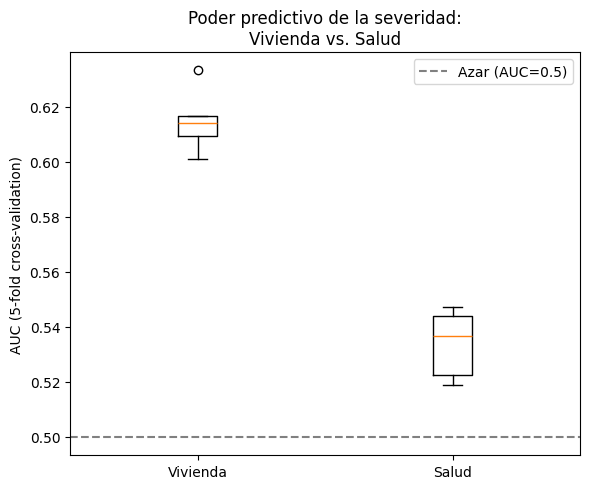

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.boxplot([resultados['Vivienda'], resultados['Salud']], labels=['Vivienda', 'Salud'])
plt.axhline(0.5, color='gray', linestyle='--', label='Azar (AUC=0.5)')
plt.ylabel('AUC (5-fold cross-validation)')
plt.title('Poder predictivo de la severidad:\nVivienda vs. Salud')
plt.legend()
plt.tight_layout()
plt.show()

17. Modelo principal: logit + Random Forest para pobreza_multi
Usamos los 76.765 hogares con dato válido de pobreza_multi (no solo los pobres), con todos los predictores no monetarios juntos, para responder la pregunta central: cuáles pesan más a la hora de explicar si un hogar cae o no en pobreza multidimensional.

In [26]:
# Defensivo: asegurar que no queden nulos en el target y que sea tipo entero (0/1)
hogares_modelo = hogares.dropna(subset=['pobreza_multi']).copy()
hogares_modelo['pobreza_multi'] = hogares_modelo['pobreza_multi'].astype(int)

print('Hogares para el modelo:', hogares_modelo.shape[0])
print(hogares_modelo['pobreza_multi'].value_counts())

predictores_modelo = [c for c in predictores if c in hogares_modelo.columns]
print('Predictores en el modelo:', len(predictores_modelo))

X = hogares_modelo[predictores_modelo].apply(pd.to_numeric, errors='coerce').fillna(0)
y = hogares_modelo['pobreza_multi']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Hogares para el modelo: 76765
pobreza_multi
0    66344
1    10421
Name: count, dtype: int64
Predictores en el modelo: 35


In [27]:
## Logit — interpretable, para ver dirección y significancia de cada predictor
from sklearn.metrics import roc_auc_score
logit = LogisticRegression(max_iter=1000, class_weight='balanced')
logit.fit(X_train_scaled, y_train)

y_pred_logit = logit.predict_proba(X_test_scaled)[:, 1]
auc_logit = roc_auc_score(y_test, y_pred_logit)
print(f'Logit — AUC en test: {auc_logit:.3f}')

coeficientes = pd.Series(logit.coef_[0], index=predictores_modelo).sort_values(key=abs, ascending=False)
print('\nTop 15 coeficientes (en valor absoluto):')
print(coeficientes.head(15))

Logit — AUC en test: 0.816

Top 15 coeficientes (en valor absoluto):
r8e   -0.234162
r8a   -0.225581
s17    0.223772
v7     0.222514
v4     0.205624
r8c   -0.195401
v3     0.187652
v5     0.148507
r8b   -0.145560
r7e    0.121810
v2     0.119946
v6     0.115881
r7c    0.112091
v13    0.082827
r8d   -0.075815
dtype: float64


In [28]:
## Random Forest — mejor ajuste, con importancia de variables
rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

y_pred_rf = rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_pred_rf)
print(f'Random Forest — AUC en test: {auc_rf:.3f}')

importancias_rf = pd.Series(rf.feature_importances_, index=predictores_modelo).sort_values(ascending=False)
print('\nTop 15 variables más importantes (Random Forest):')
print(importancias_rf.head(15))

Random Forest — AUC en test: 0.839

Top 15 variables más importantes (Random Forest):
r8c    0.137512
r8b    0.113513
r8e    0.104953
r8a    0.095359
r8d    0.064107
v7     0.057143
v3     0.056983
v5     0.044778
r8g    0.039582
r7a    0.035375
r8f    0.034985
r7b    0.027667
v4     0.023032
r7f    0.020353
r7d    0.019587
dtype: float64


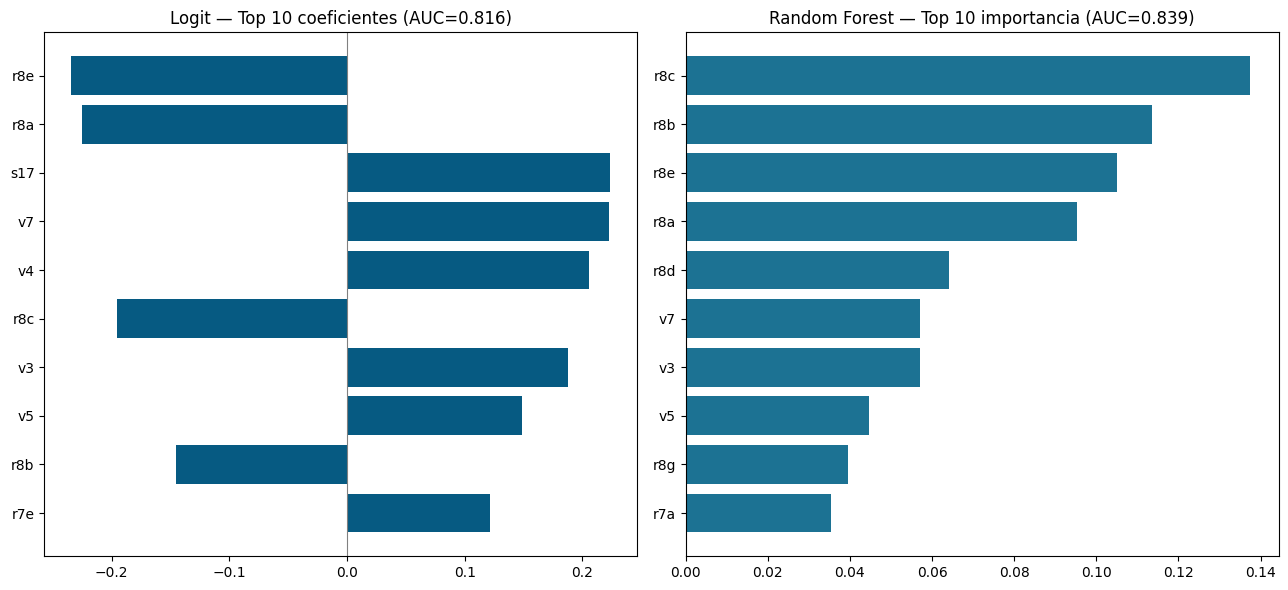

In [29]:
## Comparación visual: Logit vs. Random Forest
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

top_logit = coeficientes.head(10)
axes[0].barh(top_logit.index[::-1], top_logit.values[::-1], color='#065A82')
axes[0].set_title(f'Logit — Top 10 coeficientes (AUC={auc_logit:.3f})')
axes[0].axvline(0, color='gray', linewidth=0.8)

top_rf = importancias_rf.head(10)
axes[1].barh(top_rf.index[::-1], top_rf.values[::-1], color='#1C7293')
axes[1].set_title(f'Random Forest — Top 10 importancia (AUC={auc_rf:.3f})')

plt.tight_layout()
plt.show()

18. Sumar participación en organizaciones (r6) y discriminación (r9)

In [31]:
# r9: son múltiples ítems de discriminación por distintos motivos — armamos un conteo total
r9_items = ['r9a', 'r9b', 'r9u', 'r9c', 'r9d', 'r9e', 'r9f', 'r9g', 'r9h', 'r9i', 'r9j', 'r9k', 'r9l', 'r9m', 'r9n', 'r9o', 'r9p', 'r9q', 'r9r', 'r9s']
r9_items = [c for c in r9_items if c in hogares.columns]

# Recodificar cada ítem: 1 = Sí lo vivió -> 1, 2 = No -> 0, y sumar
r9_dummies = hogares[r9_items].apply(lambda col: (col == 1).astype(int))
hogares['veces_discriminado'] = r9_dummies.sum(axis=1)

predictores_nuevos = ['r6', 'veces_discriminado']
predictores_nuevos = [c for c in predictores_nuevos if c in hogares.columns]
print('Nuevos predictores agregados:', predictores_nuevos)

predictores = predictores + [c for c in predictores_nuevos if c not in predictores]
print('Total predictores actualizado:', len(predictores))

Nuevos predictores agregados: ['r6', 'veces_discriminado']
Total predictores actualizado: 37


19. Vulnerabilidad: reconstruir el conteo de carencias y comparar dentro de los NO pobres

In [30]:
# Los 20 indicadores oficiales de la metodología 2024 (sin los "_2015", que son de la serie histórica)
indicadores_2024 = ['hh_d_asis', 'hh_d_rez', 'hh_d_esc', 'hh_d_ape', 'hh_d_acc', 'hh_d_ali',
                     'hh_d_contprev', 'hh_d_dpf', 'hh_d_actsub', 'hh_d_inf', 'hh_d_jub', 'hh_d_cui',
                     'hh_d_defcuali', 'hh_d_defcuanti', 'hh_d_accesi', 'hh_d_medio', 'hh_d_apoyo',
                     'hh_d_tsocial', 'hh_d_conec', 'hh_d_seg']
indicadores_2024 = [c for c in indicadores_2024 if c in hogares_modelo.columns]
print('Indicadores encontrados:', len(indicadores_2024), 'de 20')

# Conteo de carencias por hogar (0 a 20)
hogares_modelo['n_carencias'] = hogares_modelo[indicadores_2024].apply(pd.to_numeric, errors='coerce').sum(axis=1)

# Clasificación de vulnerabilidad, solo entre los NO pobres (pobreza_multi == 0)
no_pobres = hogares_modelo[hogares_modelo['pobreza_multi'] == 0].copy()
no_pobres['vulnerable'] = (no_pobres['n_carencias'] >= 3).astype(int)  # 3-4 carencias = cerca del umbral de 5

print(no_pobres['vulnerable'].value_counts(normalize=True) * 100)
print('\nDistribución de n_carencias entre los no pobres:')
print(no_pobres['n_carencias'].value_counts().sort_index())

Indicadores encontrados: 20 de 20
vulnerable
0    67.751417
1    32.248583
Name: proportion, dtype: float64

Distribución de n_carencias entre los no pobres:
n_carencias
0    11196
1    17071
2    16682
3    12936
4     8459
Name: count, dtype: int64


In [32]:
## Modelo: ¿qué predice ser vulnerable (vs. no vulnerable) entre los hogares no pobres?
predictores_vuln = [c for c in predictores if c in no_pobres.columns and not c.startswith('hh_d_')]

X = no_pobres[predictores_vuln].apply(pd.to_numeric, errors='coerce').fillna(0)
y = no_pobres['vulnerable']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

rf_vuln = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, class_weight='balanced')
rf_vuln.fit(X_train, y_train)

auc_vuln = roc_auc_score(y_test, rf_vuln.predict_proba(X_test)[:, 1])
print(f'AUC (vulnerable vs. no vulnerable, dentro de los no pobres): {auc_vuln:.3f}')

importancias_vuln = pd.Series(rf_vuln.feature_importances_, index=predictores_vuln).sort_values(ascending=False)
print(importancias_vuln.head(15))

AUC (vulnerable vs. no vulnerable, dentro de los no pobres): 0.745
r8c    0.098631
r8b    0.097325
v3     0.073264
r8e    0.065911
r7a    0.065299
r8a    0.063743
v7     0.062597
s13    0.057717
v5     0.052745
v4     0.044556
r8d    0.036241
r7g    0.029801
r7b    0.029191
r7i    0.023604
v6     0.021403
dtype: float64
